# SPX Implied Volatility Surface: SVI vs. Cubic Spline Out-of-Sample Performance

This notebook recovers SPX implied volatility from observed option quotes, then compares SVI (a parametric surface model) against a cubic spline (a non-parametric fit) on out-of-sample accuracy.

The question: when does a smooth parametric surface generalize better than a flexible local fit, and when does the reverse hold? Both models are calibrated on randomly held-out subsets of each day's smile and evaluated on the withheld points, across maturity, moneyness, and data availability.

Pipeline: clean the raw option quotes and market inputs, recover implied volatility via Newton-Raphson inversion of Black-Scholes, calibrate SVI and a cubic spline, then compare their out-of-sample error.

In [38]:
import os
import sys
from scipy.optimize import least_squares
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(rf"C:\Users\{os.getlogin()}\spx-options-pricing-research\src")

import clean_options_data as cod
import clean_market_inputs as cmi
import implied_vol as iv
import build_iv_surface as biv

# load cleaned options data and market inputs (rates, dividends), then join
options_df_raw = cod.clean_options_data()
rates_df = cmi.load_treasury_rates()
dividends_df = cmi.load_dividend_yield()

options_df = cmi.join_market_inputs(
    options_df=options_df_raw, rates_df=rates_df, dividends_df=dividends_df
)

options_df[
    ["QUOTE_DATE", "EXPIRE_DATE", "DTE", "STRIKE", "OPTION_TYPE", "UNDERLYING_LAST", "MID", "r", "q"]
].tail()

,QUOTE_DATE,EXPIRE_DATE,DTE,STRIKE,OPTION_TYPE,UNDERLYING_LAST,MID,r,q
1939632,2013-08-16,2013-08-30,14.0,1700,put,1655.93,47.200,0.0005,0.0202
1939633,2013-08-16,2013-08-30,14.0,1705,call,1655.93,1.195,0.0005,0.0202
1939634,2013-08-16,2013-08-30,14.0,1705,put,1655.93,51.700,0.0005,0.0202
1939635,2013-08-16,2013-08-30,14.0,1710,call,1655.93,0.830,0.0005,0.0202
1939636,2013-08-16,2013-08-30,14.0,1710,put,1655.93,56.345,0.0005,0.0202


### Implied Volatility Recovery

Each option's implied volatility is recovered by inverting the
Black-Scholes price via vectorized Newton-Raphson, using the market
midpoint as the target price.

In [39]:
options_df["IV_obs"] = iv.implied_volatility_vectorized(
    S=options_df["UNDERLYING_LAST"],
    K=options_df["STRIKE"],
    T=options_df["DTE"] / 365,
    r=options_df["r"],
    q=options_df["q"],
    market_price=options_df["MID"],
    option_type=options_df["OPTION_TYPE"],
)

print("IV recovery rate:", options_df["IV_obs"].notna().mean())

IV recovery rate: 0.6528979391504699


### Filtering to Well-Conditioned Observations

Contracts with low vega at the initial guess are numerically unstable
to invert, and small pricing noise translates into large swings in
recovered IV. Observations with vega below 1 or without a converged
solution are dropped before further analysis.

In [40]:
options_df["vega_initial"] = iv.black_scholes_vega(
    S=options_df["UNDERLYING_LAST"],
    K=options_df["STRIKE"],
    T=options_df["DTE"] / 365,
    r=options_df["r"],
    sigma=0.20,
    q=options_df["q"],
)

options_df = options_df[
    (options_df["vega_initial"] >= 1) & options_df["IV_obs"].notna()
].copy()

print(options_df.shape)

(1206219, 19)


### Building the Surface Inputs

Recovered IVs are converted to log-moneyness and total variance,
the coordinates used by both SVI and the spline comparison, using
each contract's forward price implied by the interpolated rate and
dividend yield.

In [41]:
# %%
options_df["T"] = options_df["DTE"] / 365
options_df["F"] = options_df["UNDERLYING_LAST"] * np.exp((options_df["r"] - options_df["q"]) * options_df["T"])
options_df["log_moneyness"] = np.log(options_df["STRIKE"] / options_df["F"])
options_df["total_variance"] = options_df["IV_obs"] ** 2 * options_df["T"]

options_df[["log_moneyness", "total_variance"]].describe()

,log_moneyness,total_variance
count,1.206219e+06,1.206219e+06
mean,-4.528205e-02,3.381827e-02
std,1.981134e-01,4.987556e-02
min,-1.177643e+00,1.302531e-05
25%,-1.459943e-01,3.876821e-03
50%,-2.627405e-02,1.295333e-02
75%,6.677959e-02,4.241537e-02
max,1.045194e+00,5.006012e-01


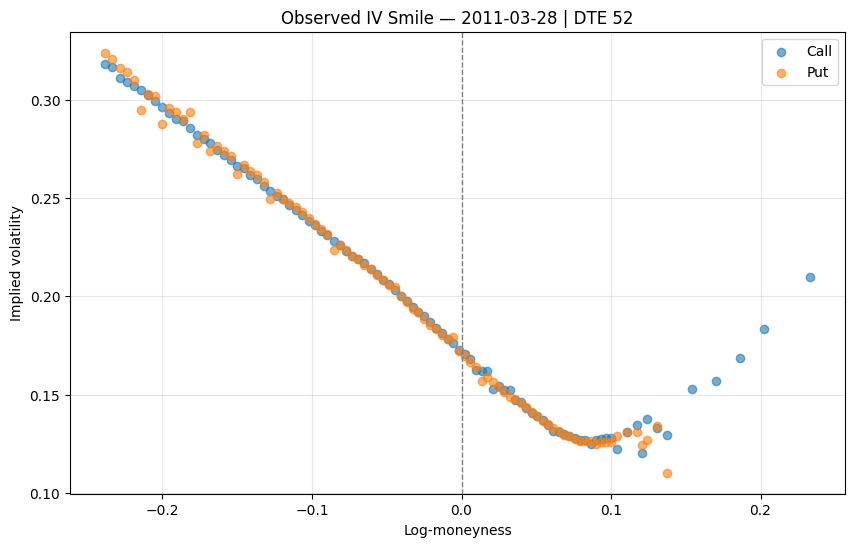

In [42]:
random_date = options_df["QUOTE_DATE"].sample(1, random_state=27).iloc[0]
day = options_df[options_df["QUOTE_DATE"] == random_date].copy()

dte_counts = day.groupby("DTE").size().sort_values(ascending=False)
selected_dte = dte_counts.index[0]

smile = day[day["DTE"] == selected_dte].sort_values("log_moneyness")

plt.figure(figsize=(10, 6))

for option_type, group in smile.groupby("OPTION_TYPE"):
    plt.scatter(group["log_moneyness"], group["IV_obs"], alpha=0.6, label=option_type.capitalize())

plt.xlabel("Log-moneyness")
plt.ylabel("Implied volatility")
plt.title(f"Observed IV Smile — {pd.Timestamp(random_date).date()} | DTE {selected_dte:.0f}")
plt.axvline(0, linestyle="--", linewidth=1, color="gray")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Fitting SVI and Spline to a Single Smile

Before running a systematic out-of-sample comparison, it's worth
confirming both models fit sensibly on real data. SVI and a cubic
spline are each calibrated on the full set of observed points for
this smile, then plotted against the raw quotes.


Note: the spline overfits noise near log-moneyness 0.10–0.15,
where data thins out, while SVI's smoother global form doesn't. The
OOS test below checks whether that in-sample flexibility actually
generalizes.

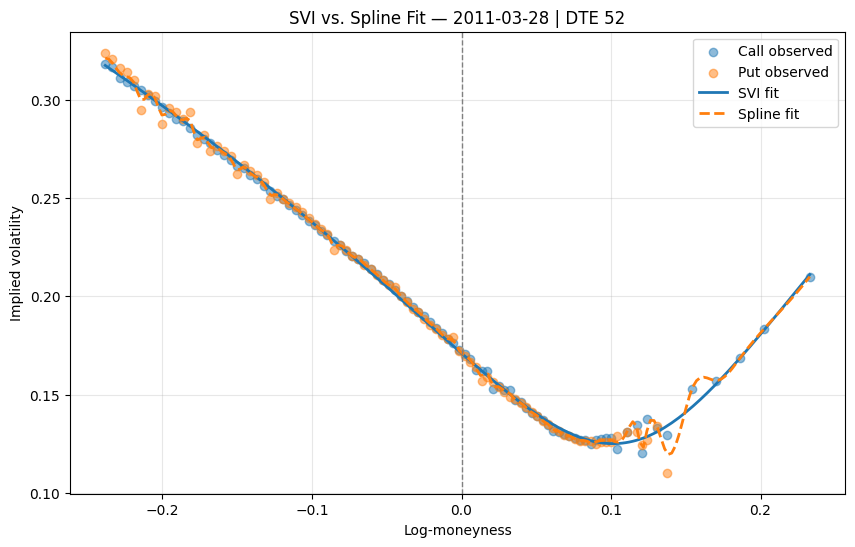

In [45]:
k = smile["log_moneyness"].to_numpy()
total_variance = smile["total_variance"].to_numpy()

svi_params = biv.calibrate_svi(k=k, total_variance=total_variance)

spline = biv.fit_spline(smile)

k_grid = np.linspace(smile["log_moneyness"].min(), smile["log_moneyness"].max(), 200)

svi_total_var_fit = biv.svi_total_variance(k_grid, *svi_params)
svi_iv_fit = np.sqrt(svi_total_var_fit / smile["T"].iloc[0])
spline_iv_fit = spline(k_grid)

plt.figure(figsize=(10, 6))

for option_type, group in smile.groupby("OPTION_TYPE"):
    plt.scatter(group["log_moneyness"], group["IV_obs"], alpha=0.5, label=f"{option_type.capitalize()} observed")

plt.plot(k_grid, svi_iv_fit, label="SVI fit", linewidth=2)
plt.plot(k_grid, spline_iv_fit, label="Spline fit", linewidth=2, linestyle="--")

plt.xlabel("Log-moneyness")
plt.ylabel("Implied volatility")
plt.title(f"SVI vs. Spline Fit — {pd.Timestamp(random_date).date()} | DTE {selected_dte:.0f}")
plt.axvline(0, linestyle="--", linewidth=1, color="gray")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Out-of-Sample Evaluation Design

To test generalization rather than in-sample fit, each day/maturity
smile is randomly split into a training subset and a held-out test
subset. SVI and the spline are calibrated on the training points only,
then evaluated on the held-out points using RMSE in implied volatility.
This is repeated across all available day/maturity slices to build an
aggregate picture of which model generalizes better, and where.

In [50]:
test_frac = 0.2
seed = 42

rng = np.random.default_rng(seed)

options_df["is_test"] = False

grouped = options_df.groupby(["QUOTE_DATE", "EXPIRE_DATE", "DTE"])

for _, group in grouped:
    n_test = max(1, int(len(group) * test_frac))
    test_idx = rng.choice(group.index, size=n_test, replace=False)
    options_df.loc[test_idx, "is_test"] = True

print("Train rows:", (~options_df["is_test"]).sum())
print("Test rows:", options_df["is_test"].sum())

options_df.to_parquet(rf"C:\Users\{os.getlogin()}\spx-options-pricing-research\outputs\holdout_assignment.parquet")

Train rows: 970315
Test rows: 235904


### Running the Out-of-Sample Evaluation

For each day/maturity slice with enough training points, SVI and the
spline are calibrated on the training subset only, then evaluated on
the held-out test points using RMSE in implied volatility. Results are
collected per slice so error can later be broken down by maturity,
moneyness, and sample size.

In [ ]:
results = []

grouped = options_df.groupby(["QUOTE_DATE", "EXPIRE_DATE", "DTE"])

for (quote_date, expire_date, dte), group in grouped:
    train = group[~group["is_test"]].dropna(subset=["log_moneyness", "total_variance", "IV_obs"])
    test = group[group["is_test"]].dropna(subset=["log_moneyness", "total_variance", "IV_obs"])

    if len(train) < 5 or len(test) < 1:
        continue

    T = group["T"].iloc[0]
    k_train = train["log_moneyness"].to_numpy()
    total_variance_train = train["total_variance"].to_numpy()
    k_test = test["log_moneyness"].to_numpy()
    iv_test = test["IV_obs"].to_numpy()

    # SVI
    try:
        svi_params = biv.calibrate_svi(k=k_train, total_variance=total_variance_train)
        svi_total_var_pred = biv.svi_total_variance(k_test, *svi_params)
        svi_iv_pred = np.sqrt(svi_total_var_pred / T)
        svi_rmse = np.sqrt(np.mean((svi_iv_pred - iv_test) ** 2))
    except Exception:
        svi_rmse = np.nan

    # Spline
    spline = biv.fit_spline(train)
    if spline is not None:
        spline_iv_pred = spline(k_test)
        spline_rmse = np.sqrt(np.mean((spline_iv_pred - iv_test) ** 2))
    else:
        spline_rmse = np.nan

    results.append({
        "QUOTE_DATE": quote_date,
        "EXPIRE_DATE": expire_date,
        "DTE": dte,
        "train_count": len(train),
        "test_count": len(test),
        "svi_rmse": svi_rmse,
        "spline_rmse": spline_rmse,
    })

results_df = pd.DataFrame(results)


In [55]:
results_df.to_parquet(
    rf"C:\Users\{os.getlogin()}\spx-options-pricing-research\outputs\oos_results.parquet"
)
print(results_df.shape)
results_df.head()

(13194, 7)


,QUOTE_DATE,EXPIRE_DATE,DTE,train_count,test_count,svi_rmse,spline_rmse
0,2010-03-31,2010-04-15,15.0,78,19,0.004298,0.007823
1,2010-03-31,2010-05-20,50.0,143,35,0.000923,0.003800
2,2010-03-31,2010-06-17,78.0,132,32,0.002721,0.011413
3,2010-03-31,2010-06-29,90.0,37,9,0.004072,0.003995
4,2010-03-31,2010-07-15,106.0,44,11,0.002492,0.003466


### Aggregate Out-of-Sample Results

Overall RMSE and win-rate across all evaluated slices, before breaking
results down by maturity, date, and training sample size.

Note: SVI wins on RMSE in the large majority of slices, and its
error distribution is fairly tight. The spline's median error is only
moderately worse, but a long tail of slices, likely sparse ones,
produce very large errors, pulling its mean far above its median.
The breakdowns below test whether that tail is explained by training
sample size.

In [56]:
valid_results = results_df.dropna(subset=["svi_rmse", "spline_rmse"])

summary = pd.DataFrame({
    "Model": ["SVI", "Spline"],
    "Mean RMSE": [valid_results["svi_rmse"].mean(), valid_results["spline_rmse"].mean()],
    "Median RMSE": [valid_results["svi_rmse"].median(), valid_results["spline_rmse"].median()],
    "Win rate": [
        (valid_results["svi_rmse"] < valid_results["spline_rmse"]).mean(),
        (valid_results["spline_rmse"] < valid_results["svi_rmse"]).mean(),
    ],
})

summary

,Model,Mean RMSE,Median RMSE,Win rate
0,SVI,0.008754,0.006645,0.938283
1,Spline,0.034671,0.011391,0.061717


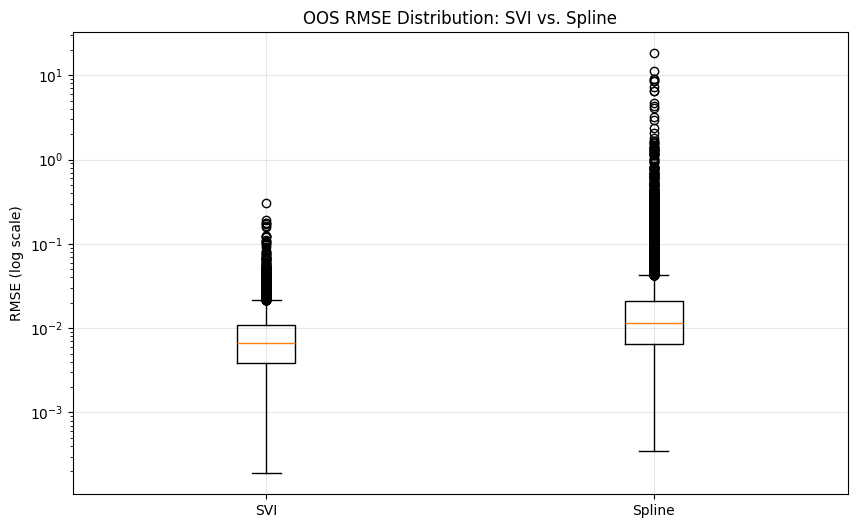

In [60]:
plt.figure(figsize=(10, 6))
plt.boxplot([valid_results["svi_rmse"], valid_results["spline_rmse"]], tick_labels=["SVI", "Spline"])
plt.yscale("log")
plt.ylabel("RMSE (log scale)")
plt.title("OOS RMSE Distribution: SVI vs. Spline")
plt.grid(True, alpha=0.3)
plt.show()

In [59]:
worst_spline = valid_results.sort_values("spline_rmse", ascending=False).head(20)
worst_spline[["QUOTE_DATE", "DTE", "train_count", "test_count", "svi_rmse", "spline_rmse"]]

,QUOTE_DATE,DTE,train_count,test_count,svi_rmse,spline_rmse
12147,2013-05-24,35.00,112,27,0.019686,18.248323
12396,2013-06-14,370.00,72,18,0.013900,11.111354
11899,2013-05-06,591.04,88,21,0.009436,9.160303
13093,2013-08-08,315.00,73,18,0.027853,8.918662
11860,2013-05-02,413.00,72,17,0.159213,8.606610
12081,2013-05-20,213.04,95,23,0.103353,8.493677
11936,2013-05-08,407.00,72,18,0.012369,7.261850
12119,2013-05-22,239.04,64,15,0.025916,6.490401
12428,2013-06-18,366.00,72,18,0.019844,6.475394
12518,2013-06-26,50.00,172,43,0.028973,4.639277


### RMSE by Training Sample Size

If the spline's large errors are driven by overfitting in sparse
smiles, error should shrink toward SVI's as training sample size
increases. Slices are grouped into bins by number of training points,
and both mean and median RMSE are shown per bin, since the mean is
sensitive to a small number of very large spline errors.

Note: median RMSE tells a consistent story. SVI outperforms the
spline in every bucket, including the largest. Mean RMSE, however,
does not shrink monotonically with more data; the spline's mean is
actually worse in the two largest buckets than in several smaller
ones. This suggests the spline's catastrophic errors aren't purely a
small-sample effect, and are worth investigating directly rather than
assumed to be explained by training sample size alone.

In [62]:
valid_results = results_df.dropna(subset=["svi_rmse", "spline_rmse"]).copy()

valid_results["train_count_bucket"] = pd.cut(
    valid_results["train_count"], bins=[0, 10, 20, 30, 50, 100, float("inf")]
)

bucket_summary = valid_results.groupby("train_count_bucket", observed=True).agg(
    svi_mean=("svi_rmse", "mean"),
    svi_median=("svi_rmse", "median"),
    spline_mean=("spline_rmse", "mean"),
    spline_median=("spline_rmse", "median"),
    n_slices=("svi_rmse", "size"),
)

bucket_summary

,svi_mean,svi_median,spline_mean,spline_median,n_slices
train_count_bucket,,,,,
"(0.0, 10.0]",0.018948,0.011279,0.021060,0.014728,56
"(10.0, 20.0]",0.013378,0.006378,0.023208,0.009018,178
"(20.0, 30.0]",0.010950,0.006557,0.018663,0.010205,608
"(30.0, 50.0]",0.007782,0.004906,0.018698,0.008306,2197
"(50.0, 100.0]",0.008707,0.006855,0.040275,0.011918,7575
"(100.0, inf]",0.008664,0.007214,0.036694,0.012528,2559


In [64]:
worst_spline = valid_results.sort_values("spline_rmse", ascending=False).head(30)

worst_spline[[
    "QUOTE_DATE", "DTE", "train_count", "test_count", "svi_rmse", "spline_rmse"
]]

,QUOTE_DATE,DTE,train_count,test_count,svi_rmse,spline_rmse
12147,2013-05-24,35.00,112,27,0.019686,18.248323
12396,2013-06-14,370.00,72,18,0.013900,11.111354
11899,2013-05-06,591.04,88,21,0.009436,9.160303
13093,2013-08-08,315.00,73,18,0.027853,8.918662
11860,2013-05-02,413.00,72,17,0.159213,8.606610
12081,2013-05-20,213.04,95,23,0.103353,8.493677
11936,2013-05-08,407.00,72,18,0.012369,7.261850
12119,2013-05-22,239.04,64,15,0.025916,6.490401
12428,2013-06-18,366.00,72,18,0.019844,6.475394
12518,2013-06-26,50.00,172,43,0.028973,4.639277


### RMSE by Maturity

Checking whether the spline's largest OOS errors are concentrated in
longer-dated maturities, which tend to have thinner liquidity and
wider bid-ask spreads, as a plausible driver of the noisy, unexplained
tail seen above that training sample size alone didn't account for.

Note: both models perform worst at the shortest and longest
maturities, but the spline's mean RMSE degrades far more severely
than its median in these buckets. Its mean-to-median ratio balloons
to 3-4x at the long end, versus a fairly stable ~1.2-1.5x for SVI.
This matches the DTE ranges with the thinnest SPX liquidity, and
supports quote noise (not sample size) as the likely driver of the
spline's tail risk.

In [66]:
valid_results["DTE_BUCKET"] = pd.cut(
    valid_results["DTE"], bins=[0, 30, 90, 180, 365, 730, float("inf")]
)

dte_summary = valid_results.groupby("DTE_BUCKET", observed=True).agg(
    svi_median=("svi_rmse", "median"),
    spline_median=("spline_rmse", "median"),
    svi_mean=("svi_rmse", "mean"),
    spline_mean=("spline_rmse", "mean"),
    n_slices=("svi_rmse", "size"),
)

dte_summary

,svi_median,spline_median,svi_mean,spline_mean,n_slices
DTE_BUCKET,,,,,
"(0.0, 30.0]",0.011626,0.019807,0.014576,0.033944,2448
"(30.0, 90.0]",0.006627,0.011158,0.008276,0.035903,2311
"(90.0, 180.0]",0.005016,0.008629,0.006638,0.020598,2311
"(180.0, 365.0]",0.004920,0.008638,0.006218,0.028262,3493
"(365.0, 730.0]",0.006539,0.010891,0.007935,0.049892,1788
"(730.0, inf]",0.009250,0.015907,0.011276,0.067057,822


### Summary: Where Each Model Wins

A single view combining the maturity breakdown: median RMSE (typical
case) and mean RMSE (tail-sensitive) side by side, showing both that
SVI wins broadly and where the spline's tail risk concentrates.

Note: SVI's error stays flat and tight across the entire sample.
The spline's error is noisier throughout and grows both more frequent
and more extreme from around 2013 onward, suggesting its tail-risk
problem isn't confined to a fixed set of conditions (maturity, sample
size) but may be worsening over time, which is a pattern worth flagging as a
direction for further investigation rather than fully explained here.

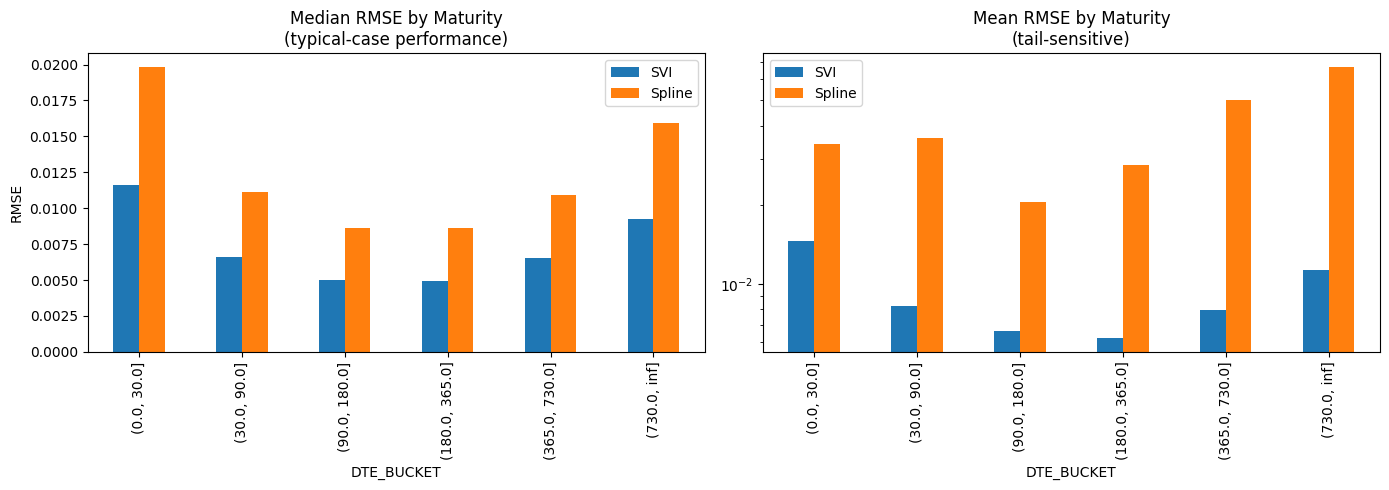

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

dte_summary[["svi_median", "spline_median"]].plot(kind="bar", ax=axes[0], color=["#1f77b4", "#ff7f0e"])
axes[0].set_title("Median RMSE by Maturity\n(typical-case performance)")
axes[0].set_ylabel("RMSE")
axes[0].legend(["SVI", "Spline"])

dte_summary[["svi_mean", "spline_mean"]].plot(kind="bar", ax=axes[1], color=["#1f77b4", "#ff7f0e"])
axes[1].set_yscale("log")
axes[1].set_title("Mean RMSE by Maturity\n(tail-sensitive)")
axes[1].legend(["SVI", "Spline"])

plt.tight_layout()
plt.show()

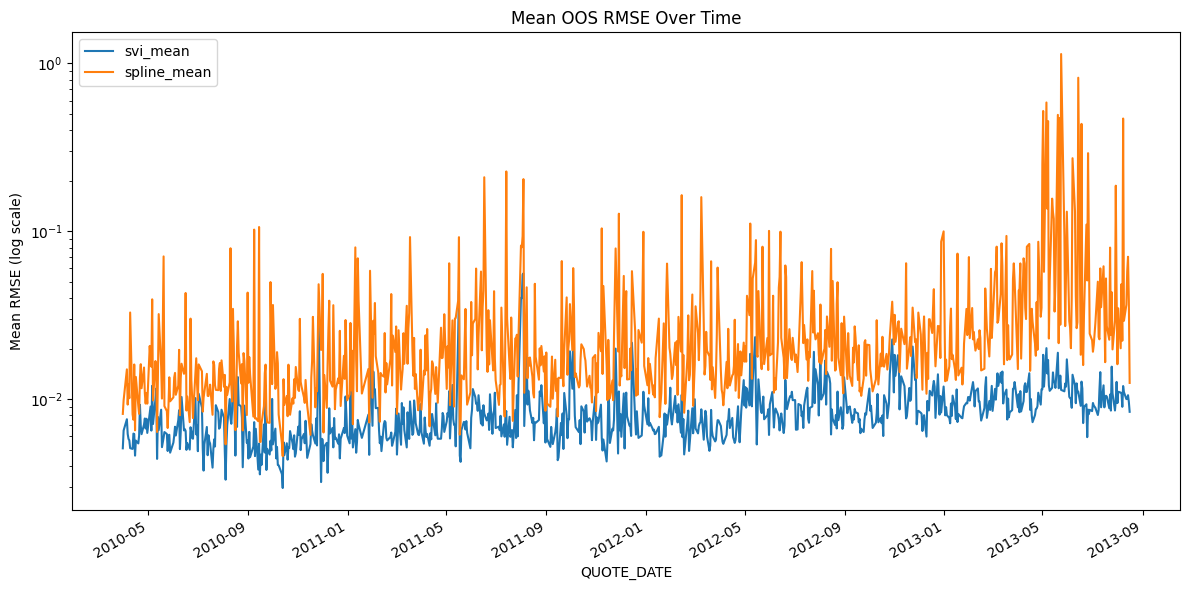

In [72]:
daily_summary = valid_results.groupby("QUOTE_DATE").agg(
    svi_mean=("svi_rmse", "mean"),
    spline_mean=("spline_rmse", "mean"),
)

daily_summary.plot(figsize=(12, 6))
plt.yscale("log")
plt.ylabel("Mean RMSE (log scale)")
plt.title("Mean OOS RMSE Over Time")
plt.tight_layout()
plt.show()